In [23]:
# Import Libraries
!pip install emoji
!pip install tqdm
import pandas as pd
import numpy as np
import re
import string
import emoji

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer

nltk.download('stopwords')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.0 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [25]:
# Load files
neg_train = pd.read_csv("train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
pos_train = pd.read_csv("train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
pos_test = pd.read_csv("test_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
neg_test = pd.read_csv("test_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)



In [26]:
train_df = (
    pd.concat([pos_train, neg_train], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

test_df = (
    pd.concat([pos_test, neg_test], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

In [27]:
for df in [train_df, test_df]:
    df.columns = ['label', 'tweet']

In [28]:
df.shape

(11520, 2)

<Axes: xlabel='label', ylabel='count'>

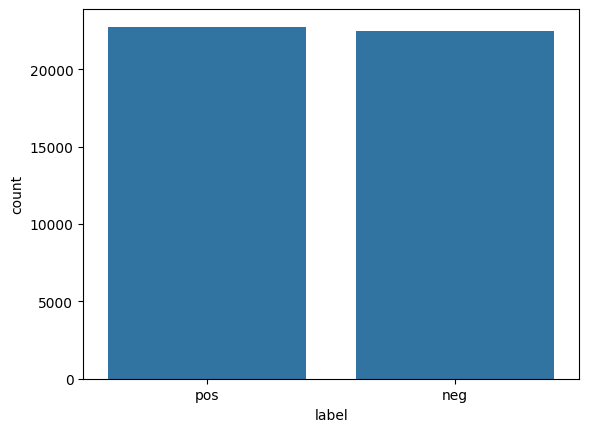

In [29]:
sns.countplot(data=train_df,x='label')

In [30]:

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emotions
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

def extract_emojis(text):
    return emoji_pattern.findall(str(text))

In [31]:
train_df["emojies"] = train_df["tweet"].apply(extract_emojis)

In [32]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [33]:
from tqdm.auto import tqdm
tqdm.pandas()

exclude=[string.punctuation]
exclude.append('﴾')
exclude.append('﴿')
exclude.append('؟')
def remove_punc(text):
  for char in exclude:
    text=text.replace(char,'')
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_punc(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_punc(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [34]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع فيه 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم من اصل بدو...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [35]:
def remove_digits(text):
  text=re.sub('\w*\d\w*','',text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_digits(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_digits(x))

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:2: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_437/1744823745.py:2: SyntaxWarning: invalid escape sequence '\w'
  text=re.sub('\w*\d\w*','',text)


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [36]:
stopwords=stopwords.words('english')
stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [37]:
def remove_stopwords(text):
  filtered_words=[word for word in text.split() if word not in stopwords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [38]:
arabic_StopWords = nltk.corpus.stopwords.words("arabic")
arabic_StopWords

['إذ',
 'إذا',
 'إذما',
 'إذن',
 'أف',
 'أقل',
 'أكثر',
 'ألا',
 'إلا',
 'التي',
 'الذي',
 'الذين',
 'اللاتي',
 'اللائي',
 'اللتان',
 'اللتيا',
 'اللتين',
 'اللذان',
 'اللذين',
 'اللواتي',
 'إلى',
 'إليك',
 'إليكم',
 'إليكما',
 'إليكن',
 'أم',
 'أما',
 'أما',
 'إما',
 'أن',
 'إن',
 'إنا',
 'أنا',
 'أنت',
 'أنتم',
 'أنتما',
 'أنتن',
 'إنما',
 'إنه',
 'أنى',
 'أنى',
 'آه',
 'آها',
 'أو',
 'أولاء',
 'أولئك',
 'أوه',
 'آي',
 'أي',
 'أيها',
 'إي',
 'أين',
 'أين',
 'أينما',
 'إيه',
 'بخ',
 'بس',
 'بعد',
 'بعض',
 'بك',
 'بكم',
 'بكم',
 'بكما',
 'بكن',
 'بل',
 'بلى',
 'بما',
 'بماذا',
 'بمن',
 'بنا',
 'به',
 'بها',
 'بهم',
 'بهما',
 'بهن',
 'بي',
 'بين',
 'بيد',
 'تلك',
 'تلكم',
 'تلكما',
 'ته',
 'تي',
 'تين',
 'تينك',
 'ثم',
 'ثمة',
 'حاشا',
 'حبذا',
 'حتى',
 'حيث',
 'حيثما',
 'حين',
 'خلا',
 'دون',
 'ذا',
 'ذات',
 'ذاك',
 'ذان',
 'ذانك',
 'ذلك',
 'ذلكم',
 'ذلكما',
 'ذلكن',
 'ذه',
 'ذو',
 'ذوا',
 'ذواتا',
 'ذواتي',
 'ذي',
 'ذين',
 'ذينك',
 'ريث',
 'سوف',
 'سوى',
 'شتان',
 'عدا',
 'عسى',
 'عل'

In [39]:
def remove_arabic_stopwords(text):
  filtered_words=[word for word in text.split() if word not in arabic_StopWords]
  return ' '.join(filtered_words)

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_arabic_stopwords(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [40]:
train_df.head(5)

,label,tweet,emojies
0,pos,مقال يدور حول الحمى يوشك ان يقع 😊,[😊]
1,pos,تيشرت القائد 💙,[💙]
2,neg,وكل السعوديه بدو ..حتى الحاضره منهم اصل بدوي 😩...,[😩]
3,neg,المونافري طلع برهوش .. سدينا 😤,[😤]
4,neg,منو خر بيتهم مثلنا 😩,[😩]


In [41]:
!pip install pyarabic
from pyarabic.araby import strip_tashkeel

def clean_arabic_text(text):
    # 1. Remove diacritics (التشكيل)
    text = strip_tashkeel(text)

    # 2. Remove Arabic + English punctuation
    arabic_punct = "،؛؟ـ«»…"
    all_punct = string.punctuation + arabic_punct
    text = text.translate(str.maketrans('', '', all_punct))

    # 3. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

train_df['tweet'] = train_df['tweet'].progress_apply(clean_arabic_text)
test_df['tweet'] = test_df['tweet'].progress_apply(clean_arabic_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.8 MB/s eta 0:00:00


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [42]:
def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : normalize_arabic(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : normalize_arabic(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [43]:
def repeated_letter(text):
  text = re.sub(r'(.)\1{2,}', r'\1', text)
  return text
train_df['tweet']=train_df['tweet'].progress_apply(lambda x : repeated_letter(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : repeated_letter(x))

  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [44]:
def arabic_english(text):
  text = re.sub(r'[^\u0600-\u06FFa-zA-Z\s]', '', text)
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : arabic_english(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : arabic_english(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

In [45]:
def remove_spaces(text):
  text = re.sub(r'\s+', ' ', text).strip()
  return text

train_df['tweet']=train_df['tweet'].progress_apply(lambda x : remove_spaces(x))
test_df['tweet']=test_df['tweet'].progress_apply(lambda x : remove_spaces(x))


  0%|          | 0/45275 [00:00<?, ?it/s]

  0%|          | 0/11520 [00:00<?, ?it/s]

##RNN Implementation

In [46]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [47]:
vocab_size = 20000
tokenizer = Tokenizer(
        num_words=vocab_size,
        oov_token="<OOV>"
)
tokenizer.fit_on_texts(train_df['tweet'])

In [48]:
train_df['text_sequences'] = tokenizer.texts_to_sequences(train_df['tweet'])
test_df['text_sequences'] = tokenizer.texts_to_sequences(test_df['tweet'])

In [49]:
for word, index in tokenizer.word_index.items():
    print(word, index)
    if index == 10:
        break

<OOV> 1
الله 2
اللهم 3
اللي 4
انا 5
والله 6
الهلال 7
ان 8
الخير 9
الي 10


In [50]:
vocab_size = len(tokenizer.word_index)

In [51]:
train_df.head(5)

,label,tweet,emojies,text_sequences
0,pos,مقال يدور حول الحمي يوشك ان يقع,[😊],"[3295, 571, 281, 1, 1, 8, 3888]"
1,pos,تيشرت القايد,[💙],"[16469, 3681]"
2,neg,وكل السعوديه بدو حتي الحاضره منهم اصل بدوي انا...,[😩],"[240, 1476, 4403, 552, 1, 530, 2712, 16470, 5,..."
3,neg,المونافري طلع برهوش سدينا,[😤],"[1, 424, 1, 1]"
4,neg,منو خر بيتهم مثلنا,[😩],"[1292, 1, 16472, 16473]"


In [52]:
# Compute sequence lengths
sequence_lengths = [len(seq) for seq in train_df['text_sequences']]

# Count frequencies of each length
length_counts = Counter(sequence_lengths)

# Prepare data for plotting
lengths = list(length_counts.keys())
counts = list(length_counts.values())

In [53]:
length_counts.most_common(5)

[(3, 3730), (2, 3643), (4, 3430), (5, 2982), (6, 2618)]

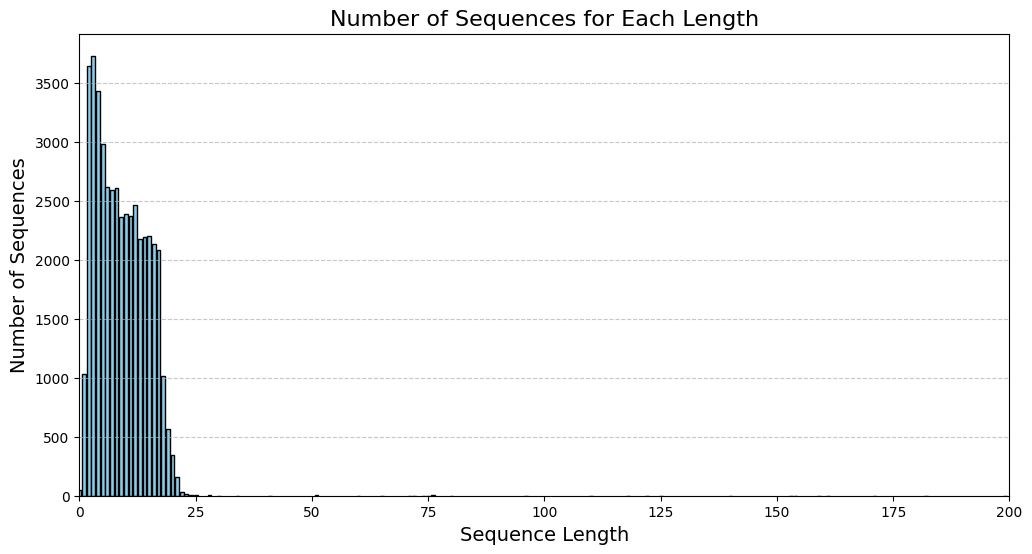

In [54]:
plt.figure(figsize=(12, 6))
plt.bar(lengths, counts, color='skyblue', edgecolor='black')

plt.title('Number of Sequences for Each Length', fontsize=16)
plt.xlabel('Sequence Length', fontsize=14)
plt.ylabel('Number of Sequences', fontsize=14)

plt.xlim(0, 200)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [55]:
input_shape = 25

In [56]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['tweet'])

In [57]:
X_train_seq = tokenizer.texts_to_sequences(train_df['tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['tweet'])

In [58]:
X_train = pad_sequences(X_train_seq, maxlen=input_shape, padding='post')
X_test = pad_sequences(X_test_seq, maxlen=input_shape, padding='post')

In [59]:
LB = LabelEncoder()
y_train = LB.fit_transform(train_df['label'])
y_test = LB.transform(test_df['label'])

In [60]:
y_train = np.array(y_train, dtype="int32")
y_test = np.array(y_test, dtype="int32")

X_train = np.array(X_train, dtype="int32")
X_test = np.array(X_test, dtype="int32")

In [61]:

model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(input_shape,)),

    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=128
    ),

    tf.keras.layers.SimpleRNN(64),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [62]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [63]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 128)        │     8,418,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,430,849 (32.16 MB)

 Trainable params: 8,430,849 (32.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [64]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [65]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6614 - loss: 0.5712
Epoch 1: val_accuracy improved from None to 0.76046, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 72s 123ms/step - accuracy: 0.7188 - loss: 0.5097 - val_accuracy: 0.7605 - val_loss: 0.4515
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.9366 - loss: 0.1592
Epoch 2: val_accuracy improved from 0.76046 to 0.76709, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 79s 119ms/step - accuracy: 0.9369 - loss: 0.1579 - val_accuracy: 0.7671 - val_loss: 0.5105
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9745 - loss: 0.0675
Epoch 3: val_accuracy did not improve from 0.76709
566/566 ━━━━━━━━━━━━━━━━━━━━ 69s 120ms/step - accuracy: 0.9718 - loss: 0.0720 - val_accuracy: 0.7662 - val_loss: 0.5957
Epoch 4/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s

In [66]:
best_model = tf.keras.models.load_model("best_model.keras")

In [67]:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.4).astype(int).flatten()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=LB.classes_
    )
)

360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

         neg       0.75      0.80      0.77      5768
         pos       0.79      0.73      0.76      5752

    accuracy                           0.77     11520
   macro avg       0.77      0.76      0.76     11520
weighted avg       0.77      0.77      0.76     11520



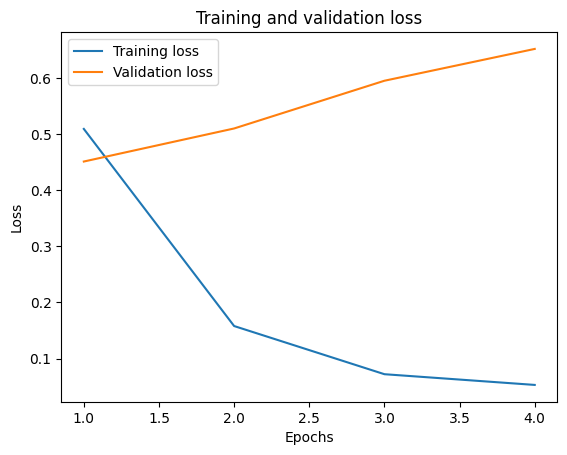

In [68]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

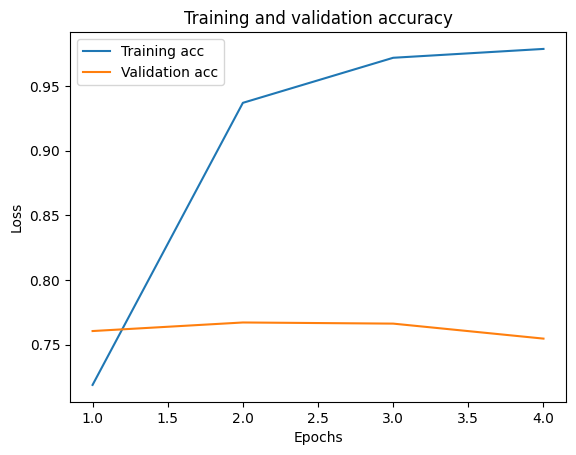

In [69]:

plt.clf()
acc_values = history.history['accuracy']
val_acc_values = history.history['val_accuracy']

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [70]:
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7650173611111111


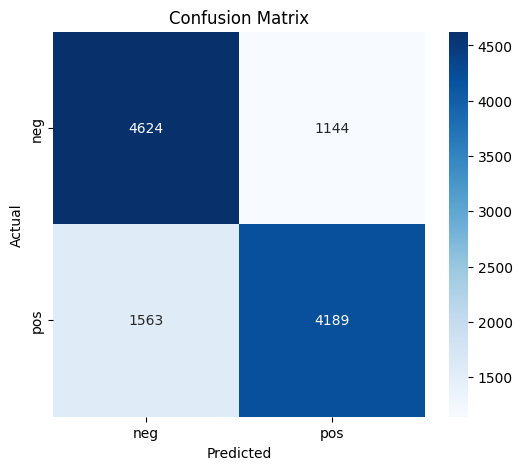

In [71]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
# Test new Sentences
new_text = [
    "الخدمة ممتازة جدا جدا",
    "سيئة للغاية ولن أكرر التجربة مرة أخرى",
    "التجربة كانت عادية"
]

seq = tokenizer.texts_to_sequences(new_text)
padded = pad_sequences(seq, maxlen=input_shape, padding='post')

pred = model.predict(padded)
pred_classes = (pred > 0.5).astype(int).flatten()

results = LB.inverse_transform(pred_classes)

for text, label in zip(new_text, results):
    print(text, " ---> ", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
الخدمة ممتازة جدا جدا  --->  pos
سيئة للغاية ولن أكرر التجربة مرة أخرى  --->  neg
التجربة كانت عادية  --->  neg


## LSTM Implementation

In [87]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder


model_lstm = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [88]:
model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [89]:
print(model_lstm.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 25, 128)        │     8,418,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,467,777 (32.30 MB)

 Trainable params: 8,467,777 (32.30 MB)

 Non-trainable params: 0 (0.00 B)

None


In [90]:
checkpoint_lstm = ModelCheckpoint(
    "best_model_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_lstm = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [91]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_lstm, early_stop_lstm]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.6429 - loss: 0.5863
Epoch 1: val_accuracy improved from None to 0.77073, saving model to best_model_lstm.keras

Epoch 1: finished saving model to best_model_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 85s 146ms/step - accuracy: 0.7150 - loss: 0.5155 - val_accuracy: 0.7707 - val_loss: 0.4412
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8861 - loss: 0.2675
Epoch 2: val_accuracy improved from 0.77073 to 0.78200, saving model to best_model_lstm.keras

Epoch 2: finished saving model to best_model_lstm.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 78s 138ms/step - accuracy: 0.8828 - loss: 0.2698 - val_accuracy: 0.7820 - val_loss: 0.4692
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9460 - loss: 0.1372
Epoch 3: val_accuracy did not improve from 0.78200
566/566 ━━━━━━━━━━━━━━━━━━━━ 77s 136ms/step - accuracy: 0.9424 - loss: 0.1426 - val_accuracy: 0.7714 - val_loss: 0.6549
Epoch 4/100
566/566 ━━━

In [92]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_df['tweet'])
vocab_size = len(tokenizer.word_index) + 1

In [93]:
best_model_lstm = tf.keras.models.load_model("best_model_lstm.keras")

In [94]:
y_pred_prob_lstm = best_model_lstm.predict(X_test)
y_pred_lstm = (y_pred_prob_lstm > 0.4).astype(int).flatten()

print(
    classification_report(
        y_test,
        y_pred_lstm,
        target_names=LB.classes_
    )
)

360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

         neg       0.78      0.74      0.76      5768
         pos       0.75      0.80      0.77      5752

    accuracy                           0.77     11520
   macro avg       0.77      0.77      0.77     11520
weighted avg       0.77      0.77      0.77     11520



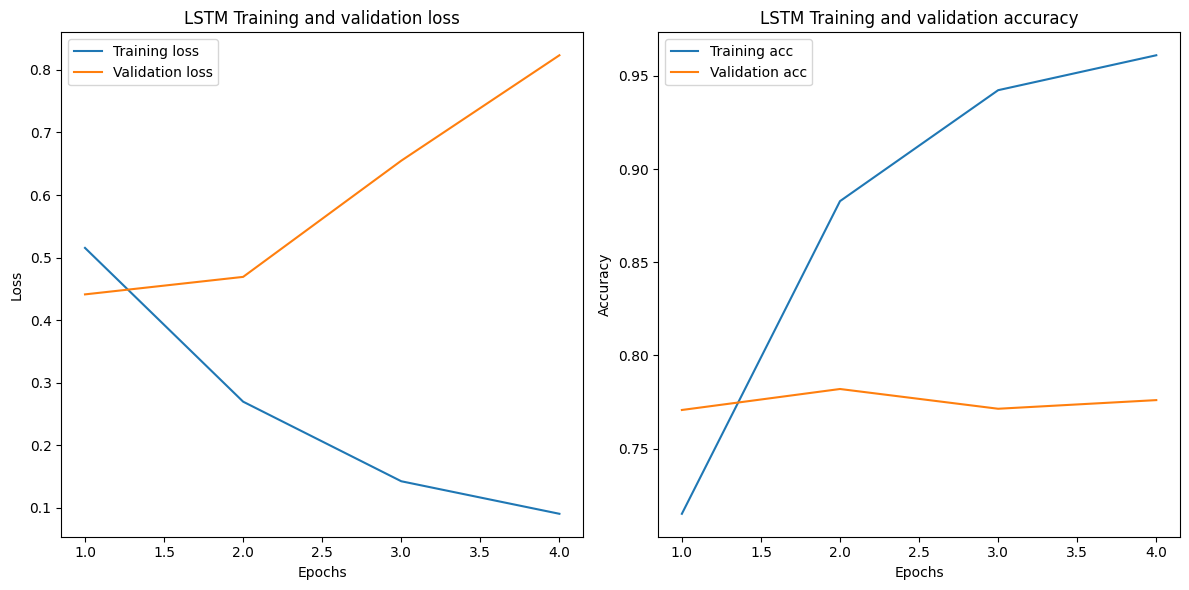

In [95]:
acc_lstm = history_lstm.history['accuracy']
val_acc_lstm = history_lstm.history['val_accuracy']
loss_lstm = history_lstm.history['loss']
val_loss_lstm = history_lstm.history['val_loss']

epochs_lstm = range(1, len(acc_lstm) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_lstm, loss_lstm, label='Training loss')
plt.plot(epochs_lstm, val_loss_lstm, label='Validation loss')
plt.title('LSTM Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_lstm, acc_lstm, label='Training acc')
plt.plot(epochs_lstm, val_acc_lstm, label='Validation acc')
plt.title('LSTM Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [96]:
print("LSTM Test Accuracy:", accuracy_score(y_test, y_pred_lstm))

LSTM Test Accuracy: 0.7684895833333333


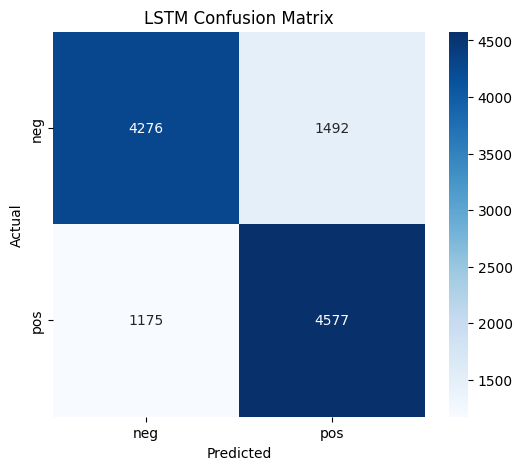

In [97]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [98]:
# Test new Sentences with LSTM model
new_text_lstm = [
    "الخدمة ممتازة جدا جدا",
    "سيئة للغاية ولن أكرر التجربة مرة أخرى",
    "التجربة كانت عادية"
]

seq_lstm = tokenizer.texts_to_sequences(new_text_lstm)
padded_lstm = pad_sequences(seq_lstm, maxlen=input_shape, padding='post')

pred_lstm = best_model_lstm.predict(padded_lstm)
pred_classes_lstm = (pred_lstm > 0.5).astype(int).flatten()

results_lstm = LB.inverse_transform(pred_classes_lstm)

print("\nLSTM Model Predictions:")
for text, label in zip(new_text_lstm, results_lstm):
    print(text, " ---> ", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step

LSTM Model Predictions:
الخدمة ممتازة جدا جدا  --->  pos
سيئة للغاية ولن أكرر التجربة مرة أخرى  --->  neg
التجربة كانت عادية  --->  pos


## GRU Implementation

In [99]:
model_gru = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Embedding(
        input_dim=vocab_size + 1,
        output_dim=128
    ),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [100]:
model_gru.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [101]:
print(model_gru.summary())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 25, 128)        │     8,418,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,455,745 (32.26 MB)

 Trainable params: 8,455,745 (32.26 MB)

 Non-trainable params: 0 (0.00 B)

None


In [102]:
checkpoint_gru = ModelCheckpoint(
    "best_model_gru.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [103]:
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint_gru, early_stop_gru]
)

Epoch 1/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.5440 - loss: 0.6624
Epoch 1: val_accuracy improved from None to 0.76345, saving model to best_model_gru.keras

Epoch 1: finished saving model to best_model_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 99s 169ms/step - accuracy: 0.6286 - loss: 0.5905 - val_accuracy: 0.7634 - val_loss: 0.4576
Epoch 2/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8523 - loss: 0.3315
Epoch 2: val_accuracy improved from 0.76345 to 0.78487, saving model to best_model_gru.keras

Epoch 2: finished saving model to best_model_gru.keras
566/566 ━━━━━━━━━━━━━━━━━━━━ 88s 155ms/step - accuracy: 0.8528 - loss: 0.3272 - val_accuracy: 0.7849 - val_loss: 0.4305
Epoch 3/100
566/566 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9435 - loss: 0.1440
Epoch 3: val_accuracy did not improve from 0.78487
566/566 ━━━━━━━━━━━━━━━━━━━━ 80s 142ms/step - accuracy: 0.9419 - loss: 0.1433 - val_accuracy: 0.7755 - val_loss: 0.5635
Epoch 4/100
566/566 ━━━━━━━

In [108]:
best_model_gru = tf.keras.models.load_model("best_model_gru.keras")

In [109]:
y_pred_prob_gru = best_model_gru.predict(X_test)
y_pred_gru = (y_pred_prob_gru > 0.4).astype(int).flatten()

print(
    classification_report(
        y_test,
        y_pred_gru,
        target_names=LB.classes_
    )
)

360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

         neg       0.79      0.76      0.77      5768
         pos       0.76      0.79      0.78      5752

    accuracy                           0.78     11520
   macro avg       0.78      0.78      0.78     11520
weighted avg       0.78      0.78      0.78     11520



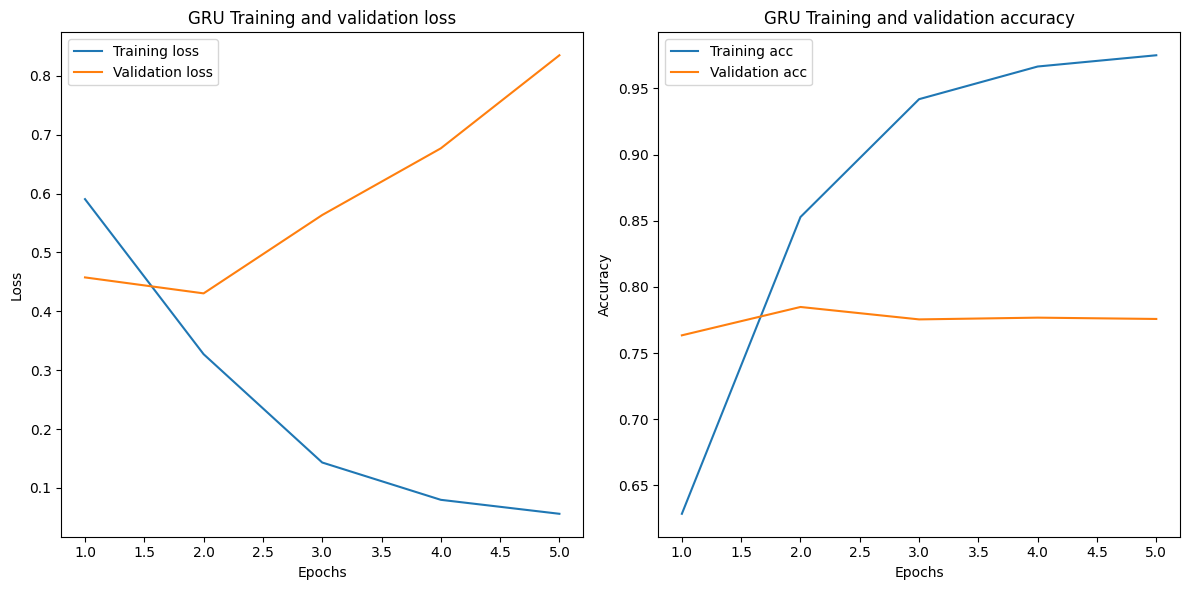

In [110]:
acc_gru = history_gru.history['accuracy']
val_acc_gru = history_gru.history['val_accuracy']
loss_gru = history_gru.history['loss']
val_loss_gru = history_gru.history['val_loss']

epochs_gru = range(1, len(acc_gru) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_gru, loss_gru, label='Training loss')
plt.plot(epochs_gru, val_loss_gru, label='Validation loss')
plt.title('GRU Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_gru, acc_gru, label='Training acc')
plt.plot(epochs_gru, val_acc_gru, label='Validation acc')
plt.title('GRU Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [111]:
print("GRU Test Accuracy:", accuracy_score(y_test, y_pred_gru))

GRU Test Accuracy: 0.7752604166666667


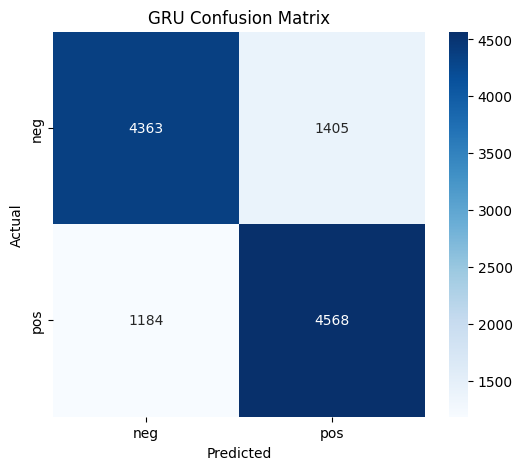

In [112]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [113]:
# Test new Sentences with GRU model
new_text_gru = [
    "الخدمة ممتازة جدا جدا",
    "سيئة للغاية ولن أكرر التجربة مرة أخرى",
    "التجربة كانت عادية"
]

seq_gru = tokenizer.texts_to_sequences(new_text_gru)
padded_gru = pad_sequences(seq_gru, maxlen=input_shape, padding='post')

pred_gru = best_model_gru.predict(padded_gru)
pred_classes_gru = (pred_gru > 0.5).astype(int).flatten()

results_gru = LB.inverse_transform(pred_classes_gru)

print("\nGRU Model Predictions:")
for text, label in zip(new_text_gru, results_gru):
    print(text, " ---> ", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step

GRU Model Predictions:
الخدمة ممتازة جدا جدا  --->  pos
سيئة للغاية ولن أكرر التجربة مرة أخرى  --->  neg
التجربة كانت عادية  --->  neg


## Model Comparison Visualizations

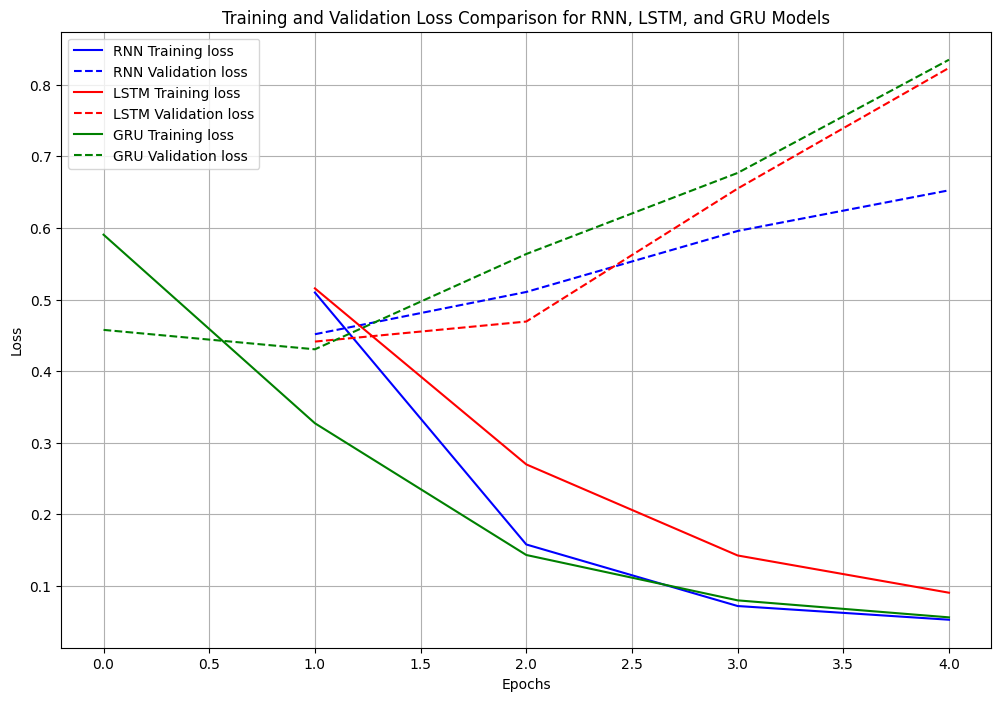

In [116]:
plt.figure(figsize=(12, 8))

# Plot RNN Loss
plt.plot(epochs, loss, label='RNN Training loss', color='blue', linestyle='-')
plt.plot(epochs, val_loss, label='RNN Validation loss', color='blue', linestyle='--')

# Plot LSTM Loss
plt.plot(epochs_lstm, loss_lstm, label='LSTM Training loss', color='red', linestyle='-')
plt.plot(epochs_lstm, val_loss_lstm, label='LSTM Validation loss', color='red', linestyle='--')

# Plot GRU Loss (assuming history_gru, loss_gru, val_loss_gru, and epochs_gru are defined)
# If history_gru was not fully trained due to error or early stopping, these might be shorter
plt.plot(history_gru.epoch, history_gru.history['loss'], label='GRU Training loss', color='green', linestyle='-')
plt.plot(history_gru.epoch, history_gru.history['val_loss'], label='GRU Validation loss', color='green', linestyle='--')

plt.title('Training and Validation Loss Comparison for RNN, LSTM, and GRU Models')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

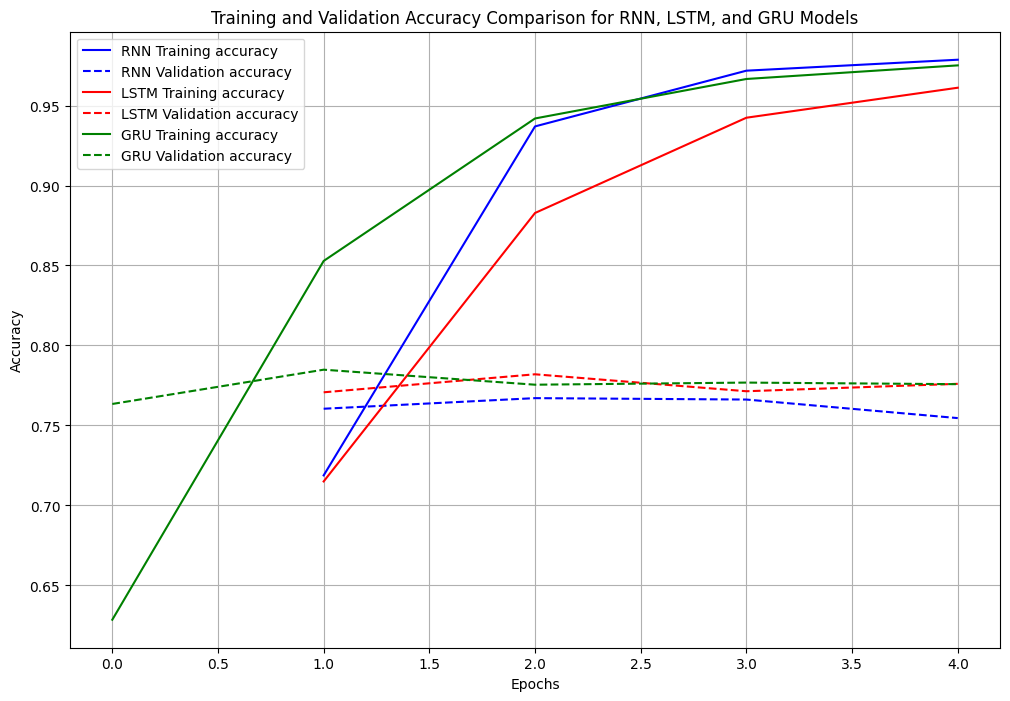

In [117]:
plt.figure(figsize=(12, 8))

# Plot RNN Accuracy
plt.plot(epochs, acc, label='RNN Training accuracy', color='blue', linestyle='-')
plt.plot(epochs, val_acc, label='RNN Validation accuracy', color='blue', linestyle='--')

# Plot LSTM Accuracy
plt.plot(epochs_lstm, acc_lstm, label='LSTM Training accuracy', color='red', linestyle='-')
plt.plot(epochs_lstm, val_acc_lstm, label='LSTM Validation accuracy', color='red', linestyle='--')

# Plot GRU Accuracy
plt.plot(history_gru.epoch, history_gru.history['accuracy'], label='GRU Training accuracy', color='green', linestyle='-')
plt.plot(history_gru.epoch, history_gru.history['val_accuracy'], label='GRU Validation accuracy', color='green', linestyle='--')

plt.title('Training and Validation Accuracy Comparison for RNN, LSTM, and GRU Models')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Confusion Matrix Comparison

360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


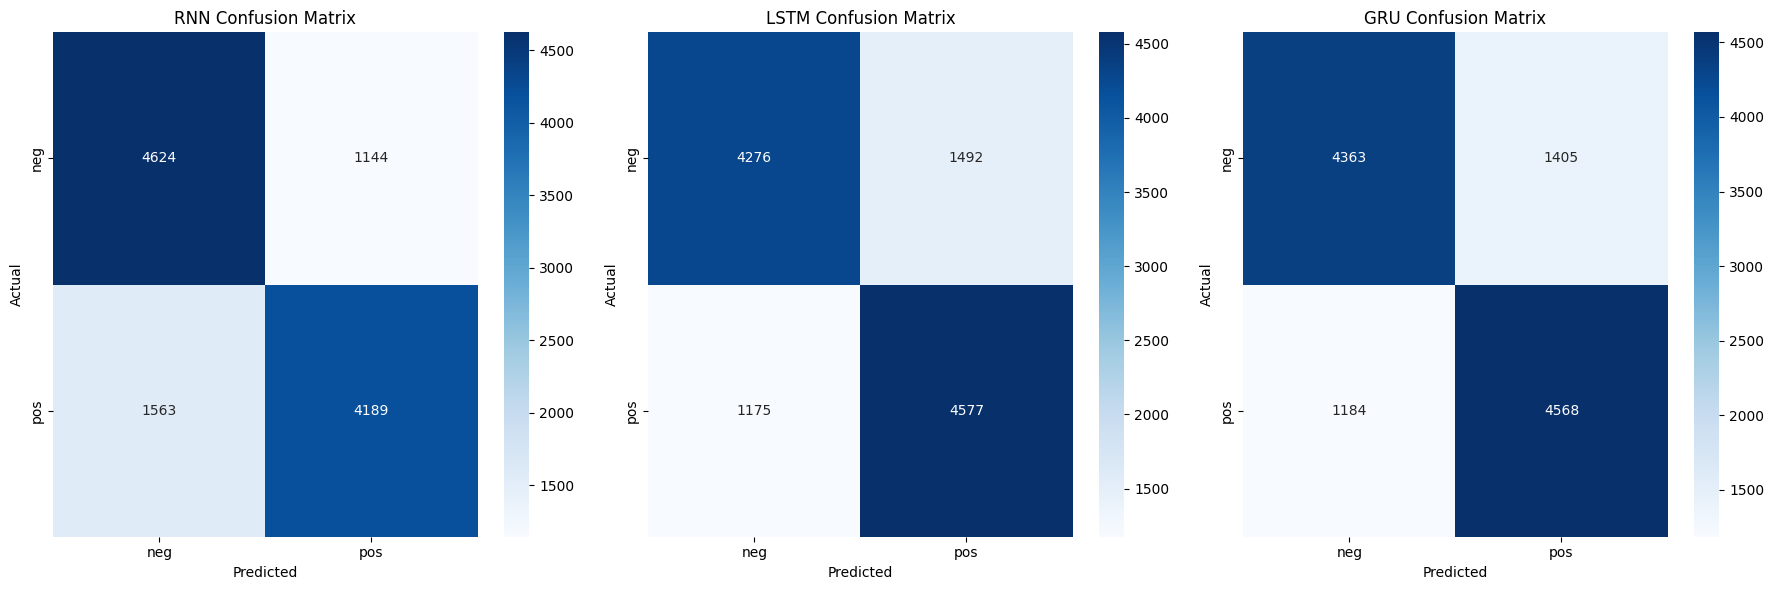

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RNN Confusion Matrix
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_,
    ax=axes[0]
)
axes[0].set_title('RNN Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# LSTM Confusion Matrix
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_,
    ax=axes[1]
)
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# GRU Confusion Matrix
# Ensure best_model_gru is loaded and predictions are made
if 'best_model_gru' not in locals():
    best_model_gru = tf.keras.models.load_model("best_model_gru.keras")
y_pred_prob_gru = best_model_gru.predict(X_test)
y_pred_gru = (y_pred_prob_gru > 0.4).astype(int).flatten()
cm_gru = confusion_matrix(y_test, y_pred_gru)

sns.heatmap(
    cm_gru,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LB.classes_,
    yticklabels=LB.classes_,
    ax=axes[2]
)
axes[2].set_title('GRU Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()